<a href="https://colab.research.google.com/github/Sk-Kamrej/Bank_Marketing_Project/blob/main/BMP_ADASYN_Advance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================
#  BANK MARKETING PROJECT (Machine Learning)
# =============================================================

In [2]:
# ==============================
# 1. INSTALL DEPENDENCIES
# ==============================
!pip install -q lightgbm catboost imbalanced-learn xgboost scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [3]:
# ==============================
# 2. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix)

from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import ADASYN
from sklearn.pipeline import Pipeline

In [4]:
# ==============================
# 3. LOAD DATASET
# ==============================
df = pd.read_csv('/content/bank-additional-full (1).csv', sep=';')

In [5]:
# ==============================
# 4. PREPROCESSING
# ==============================
df = df.drop('duration', axis=1)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

df['y'] = df['y'].map({'no': 0, 'yes': 1})

df = pd.get_dummies(df, drop_first=True)

In [6]:
# ==============================
# 5. SPLIT DATA
# ==============================
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#==============================
#SCALING
#==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#==============================
#  ADASYN
#==============================
adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_scaled, y_train)

In [7]:
# ==============================
# 6. CUSTOM METRICS
# ==============================
def specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

def gmean(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    spec = tn / (tn + fp)
    return np.sqrt(sensitivity * spec)

In [8]:
# ==============================
# 7. METRICS FUNCTION
# ==============================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy": round(accuracy_score(y_true, y_pred),4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0),4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0),4),
        "Specificity": round(tn / (tn + fp),4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0),4),
        "AUC": round(roc_auc_score(y_true, y_prob),4),
        "MCC": round(matthews_corrcoef(y_true, y_pred),4),
        "GM": round(geometric_mean_score(y_true, y_pred),4),
        "Kappa": round(cohen_kappa_score(y_true, y_pred),4)
    }

In [9]:
# ==============================
# 8. CROSS VALIDATION
# ==============================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('model', LogisticRegression(max_iter=500))
])

params = {
    "model__C": [0.01, 0.1, 0.6, 0.8, 1],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"]
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='f1', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_lr = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_lr.append({
        "Fold": fold,
        "Classifier": "Logistic Regression",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_lr = pd.DataFrame(results_lr)
display(results_df_lr)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,Logistic Regression,0.6959,0.7487,0.5889,0.8027,0.6593,0.7544,0.4009,0.6875,0.3916
1,2,Logistic Regression,0.6923,0.7382,0.5951,0.7893,0.6590,0.7487,0.3919,0.6853,0.3845
2,3,Logistic Regression,0.6864,0.7307,0.5894,0.7832,0.6525,0.7441,0.3798,0.6794,0.3727
3,4,Logistic Regression,0.6922,0.7418,0.5888,0.7955,0.6565,0.7508,0.3928,0.6844,0.3843
4,5,Logistic Regression,0.6830,0.7319,0.5764,0.7893,0.6449,0.7422,0.3744,0.6745,0.3658
5,6,Logistic Regression,0.6861,0.7340,0.5826,0.7893,0.6496,0.7469,0.3802,0.6781,0.3720
6,7,Logistic Regression,0.6979,0.7548,0.5853,0.8102,0.6593,0.7537,0.4060,0.6886,0.3956
7,8,Logistic Regression,0.6784,0.7250,0.5737,0.7828,0.6405,0.7364,0.3646,0.6701,0.3566
8,9,Logistic Regression,0.6934,0.7472,0.5841,0.8026,0.6556,0.7450,0.3963,0.6847,0.3868
9,10,Logistic Regression,0.6842,0.7382,0.5701,0.7982,0.6433,0.7427,0.3782,0.6745,0.3683


In [19]:
# ==============================
# MODEL: Decision Tree
# ==============================
from sklearn.tree import DecisionTreeClassifier

pipe = Pipeline([
    ('model', DecisionTreeClassifier())
])

params = {
    "model__max_depth": [5, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"]
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='f1', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_dt = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_dt.append({
        "Fold": fold,
        "Classifier": "Decision Tree",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_dt = pd.DataFrame(results_dt)
display(results_df_dt)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,Decision Tree,0.8674,0.9251,0.7992,0.9354,0.8576,0.9248,0.7416,0.8646,0.7347
1,2,Decision Tree,0.8670,0.9250,0.7986,0.9354,0.8571,0.9236,0.7410,0.8643,0.7340
2,3,Decision Tree,0.8680,0.9182,0.8077,0.9282,0.8594,0.9281,0.7414,0.8659,0.7360
3,4,Decision Tree,0.8667,0.9266,0.7961,0.9371,0.8564,0.9242,0.7406,0.8637,0.7333
4,5,Decision Tree,0.8708,0.9276,0.8040,0.9374,0.8614,0.9262,0.7482,0.8681,0.7415
5,6,Decision Tree,0.8682,0.9245,0.8016,0.9347,0.8587,0.9309,0.7429,0.8656,0.7364
6,7,Decision Tree,0.8740,0.9336,0.8050,0.9429,0.8646,0.9294,0.7552,0.8712,0.7480
7,8,Decision Tree,0.8648,0.9179,0.8009,0.9285,0.8554,0.9242,0.7355,0.8623,0.7295
8,9,Decision Tree,0.8708,0.9331,0.7986,0.9429,0.8606,0.9267,0.7493,0.8677,0.7415
9,10,Decision Tree,0.8764,0.9330,0.8109,0.9418,0.8677,0.9318,0.7593,0.8739,0.7528


In [11]:
# ==============================
# MODEL: Random Forest
# ==============================
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ('model', RandomForestClassifier())
])

params = {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[10,15,20],
    "model__min_samples_split":[5,10],
    "model__min_samples_leaf":[2,4],
    "model__max_features":["sqrt"],
    "model__criterion":["entropy"]
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='f1', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_rf = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_rf.append({
        "Fold": fold,
        "Classifier": "Random Forest",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_rf = pd.DataFrame(results_rf)
display(results_df_rf)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,Random Forest,0.9314,0.9442,0.9168,0.9460,0.9303,0.9784,0.8631,0.9312,0.8627
1,2,Random Forest,0.9309,0.9417,0.9185,0.9432,0.9299,0.9777,0.8620,0.9308,0.8617
2,3,Random Forest,0.9290,0.9341,0.9229,0.9350,0.9285,0.9779,0.8580,0.9289,0.8579
3,4,Random Forest,0.9336,0.9448,0.9208,0.9463,0.9327,0.9757,0.8674,0.9335,0.8672
4,5,Random Forest,0.9305,0.9385,0.9212,0.9398,0.9298,0.9776,0.8612,0.9304,0.8610
5,6,Random Forest,0.9348,0.9446,0.9236,0.9460,0.9340,0.9800,0.8698,0.9347,0.8696
6,7,Random Forest,0.9350,0.9487,0.9195,0.9504,0.9339,0.9807,0.8703,0.9348,0.8699
7,8,Random Forest,0.9242,0.9328,0.9140,0.9343,0.9233,0.9755,0.8485,0.9241,0.8483
8,9,Random Forest,0.9336,0.9454,0.9202,0.9470,0.9326,0.9789,0.8675,0.9335,0.8672
9,10,Random Forest,0.9358,0.9435,0.9270,0.9446,0.9352,0.9790,0.8718,0.9358,0.8716


In [20]:
from sklearn.ensemble import GradientBoostingClassifier

pipe = Pipeline([
    ('model', GradientBoostingClassifier())
])

params = {
    "model__n_estimators":[200,300],
    "model__learning_rate":[0.03,0.05,0.1]
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='f1', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_gb = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_gb.append({
        "Fold": fold,
        "Classifier": "Gradient Boosting",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_gb = pd.DataFrame(results_gb)
display(results_df_gb)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,Gradient Boosting,0.9291,0.9768,0.8791,0.9791,0.9254,0.9709,0.8626,0.9278,0.8583
1,2,Gradient Boosting,0.9319,0.9733,0.8880,0.9757,0.9287,0.9700,0.8671,0.9308,0.8638
2,3,Gradient Boosting,0.9310,0.9649,0.8944,0.9675,0.9283,0.9701,0.8643,0.9303,0.8620
3,4,Gradient Boosting,0.9296,0.9707,0.8859,0.9733,0.9264,0.9688,0.8626,0.9286,0.8593
4,5,Gradient Boosting,0.9291,0.9634,0.8920,0.9661,0.9263,0.9717,0.8606,0.9284,0.8583
5,6,Gradient Boosting,0.9288,0.9696,0.8852,0.9723,0.9255,0.9733,0.8608,0.9277,0.8576
6,7,Gradient Boosting,0.9332,0.9720,0.8920,0.9744,0.9303,0.9762,0.8694,0.9323,0.8665
7,8,Gradient Boosting,0.9257,0.9655,0.8828,0.9685,0.9223,0.9706,0.8545,0.9247,0.8514
8,9,Gradient Boosting,0.9332,0.9724,0.8917,0.9747,0.9303,0.9718,0.8695,0.9323,0.8665
9,10,Gradient Boosting,0.9355,0.9680,0.9007,0.9702,0.9331,0.9733,0.8730,0.9348,0.8709


In [ ]:
from xgboost import XGBClassifier

pipe = Pipeline([
    ('model', XGBClassifier(eval_metric='logloss', use_label_encoder=False))
])

params = {
    "model__n_estimators":[300,500,700],
    "model__learning_rate":[0.01,0.03,0.05],
    "model__max_depth":[3,4,5]
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='f1', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_xgb = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_xgb.append({
        "Fold": fold,
        "Classifier": "XGBoost",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_xgb = pd.DataFrame(results_xgb)
display(results_df_xgb)

In [13]:
from lightgbm import LGBMClassifier

pipe = Pipeline([
    ('model', LGBMClassifier(verbosity=-1))
])

params = {
    "model__n_estimators":[300,500],
    "model__learning_rate":[0.03,0.05],
    "model__num_leaves":[31,63,127]
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='recall', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_lgb = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_lgb.append({
        "Fold": fold,
        "Classifier": "LightGBM",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_lgb = pd.DataFrame(results_lgb)
display(results_df_lgb)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,LightGBM,0.9415,0.9742,0.9068,0.9761,0.9393,0.9765,0.8850,0.9408,0.8829
1,2,LightGBM,0.9418,0.9739,0.9078,0.9757,0.9397,0.9742,0.8857,0.9412,0.8836
2,3,LightGBM,0.9392,0.9631,0.9133,0.9651,0.9376,0.9765,0.8796,0.9388,0.8785
3,4,LightGBM,0.9387,0.9665,0.9088,0.9685,0.9368,0.9735,0.8790,0.9382,0.8774
4,5,LightGBM,0.9387,0.9624,0.9130,0.9644,0.9370,0.9764,0.8786,0.9383,0.8774
5,6,LightGBM,0.9439,0.9719,0.9140,0.9737,0.9421,0.9783,0.8893,0.9434,0.8877
6,7,LightGBM,0.9445,0.9740,0.9133,0.9757,0.9427,0.9786,0.8908,0.9440,0.8891
7,8,LightGBM,0.9363,0.9619,0.9085,0.9641,0.9344,0.9729,0.8740,0.9359,0.8726
8,9,LightGBM,0.9432,0.9726,0.9120,0.9743,0.9413,0.9764,0.8881,0.9426,0.8863
9,10,LightGBM,0.9444,0.9689,0.9181,0.9706,0.9428,0.9784,0.8900,0.9440,0.8887


In [21]:
from catboost import CatBoostClassifier

pipe = Pipeline([
    ('model', CatBoostClassifier(verbose=0))
])

params = {
    "model__iterations":[200,300,400],
    "model__depth":[4,6,8],
    "model__learning_rate":[0.03,0.05]
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='f1', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_cb = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_cb.append({
        "Fold": fold,
        "Classifier": "CatBoost",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_cb = pd.DataFrame(results_cb)
display(results_df_cb)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,CatBoost,0.9321,0.9758,0.8859,0.9781,0.9287,0.9745,0.8678,0.9309,0.8641
1,2,CatBoost,0.9375,0.9751,0.8979,0.9771,0.9349,0.9739,0.8778,0.9367,0.8751
2,3,CatBoost,0.9368,0.9715,0.8999,0.9737,0.9344,0.9739,0.8760,0.9361,0.8737
3,4,CatBoost,0.9348,0.9731,0.8941,0.9754,0.9320,0.9718,0.8724,0.9339,0.8696
4,5,CatBoost,0.9350,0.9672,0.9003,0.9696,0.9326,0.9758,0.8720,0.9343,0.8699
5,6,CatBoost,0.9384,0.9765,0.8982,0.9785,0.9357,0.9772,0.8796,0.9375,0.8767
6,7,CatBoost,0.9360,0.9729,0.8968,0.9750,0.9333,0.9786,0.8746,0.9351,0.8720
7,8,CatBoost,0.9326,0.9667,0.8958,0.9692,0.9299,0.9733,0.8674,0.9318,0.8651
8,9,CatBoost,0.9389,0.9776,0.8983,0.9795,0.9363,0.9757,0.8807,0.9380,0.8778
9,10,CatBoost,0.9416,0.9715,0.9099,0.9733,0.9397,0.9773,0.8850,0.9411,0.8833


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

pipe = Pipeline([
    ('model', CalibratedClassifierCV(estimator=LinearSVC(max_iter=1000)))
])

params = {"model__estimator__C":[0.1,0.5,1]}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='f1', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_svm = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_svm.append({
        "Fold": fold,
        "Classifier": "SVM",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_svm = pd.DataFrame(results_svm)
display(results_df_svm)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,SVM,0.6960,0.7448,0.5958,0.7962,0.6620,0.7537,0.4001,0.6887,0.3920
1,2,SVM,0.6930,0.7362,0.6005,0.7852,0.6615,0.7483,0.3926,0.6867,0.3858
2,3,SVM,0.6828,0.7218,0.5939,0.7715,0.6516,0.7440,0.3714,0.6769,0.3655
3,4,SVM,0.6900,0.7356,0.5922,0.7876,0.6562,0.7500,0.3873,0.6829,0.3799
4,5,SVM,0.6825,0.7270,0.5833,0.7815,0.6473,0.7414,0.3721,0.6751,0.3648
5,6,SVM,0.6868,0.7321,0.5881,0.7852,0.6522,0.7463,0.3808,0.6795,0.3734
6,7,SVM,0.6957,0.7468,0.5912,0.7999,0.6599,0.7540,0.3999,0.6877,0.3912
7,8,SVM,0.6763,0.7186,0.5785,0.7739,0.6410,0.7364,0.3594,0.6691,0.3525
8,9,SVM,0.6921,0.7403,0.5910,0.7930,0.6573,0.7444,0.3921,0.6846,0.3840
9,10,SVM,0.6842,0.7335,0.5779,0.7903,0.6465,0.7427,0.3768,0.6758,0.3683


In [14]:
from sklearn.neighbors import KNeighborsClassifier

pipe = Pipeline([
    ('model', KNeighborsClassifier())
])

params = {
    "model__n_neighbors":[5,7,9],
    "model__weights":['uniform','distance']
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='f1', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_knn = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_knn.append({
        "Fold": fold,
        "Classifier": "KNN",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_knn = pd.DataFrame(results_knn)
display(results_df_knn)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,KNN,0.8877,0.8345,0.9671,0.8085,0.8959,0.9439,0.7855,0.8842,0.7755
1,2,KNN,0.8937,0.8403,0.9719,0.8157,0.9014,0.9472,0.7973,0.8904,0.7875
2,3,KNN,0.8841,0.8273,0.9705,0.7979,0.8932,0.9414,0.7800,0.8800,0.7683
3,4,KNN,0.8898,0.8321,0.9764,0.8034,0.8985,0.9433,0.7915,0.8856,0.7796
4,5,KNN,0.8845,0.8261,0.9736,0.7955,0.8938,0.9415,0.7815,0.8801,0.7690
5,6,KNN,0.8845,0.8294,0.9678,0.8013,0.8932,0.9435,0.7799,0.8806,0.7690
6,7,KNN,0.8889,0.8361,0.9671,0.8109,0.8969,0.9417,0.7875,0.8855,0.7779
7,8,KNN,0.8814,0.8265,0.9650,0.7979,0.8904,0.9334,0.7737,0.8775,0.7628
8,9,KNN,0.8872,0.8293,0.9750,0.7995,0.8962,0.9389,0.7866,0.8829,0.7744
9,10,KNN,0.8918,0.8368,0.9733,0.8105,0.8999,0.9428,0.7943,0.8882,0.7837


In [ ]:
from sklearn.neural_network import MLPClassifier

pipe = Pipeline([
    ('model', MLPClassifier(max_iter=300, early_stopping=True))
])

params = {
    "model__hidden_layer_sizes":[(50,), (100,), (50,50)],
    "model__alpha":[0.0001, 0.001, 0.01]
}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='roc_auc', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_mlp = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_mlp.append({
        "Fold": fold,
        "Classifier": "MLP",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_mlp = pd.DataFrame(results_mlp)
display(results_df_mlp)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,MLP,0.8718,0.8783,0.8630,0.8806,0.8706,0.9443,0.7437,0.8718,0.7436
1,2,MLP,0.8680,0.8693,0.8661,0.8700,0.8677,0.9412,0.7361,0.8680,0.7361
2,3,MLP,0.8612,0.8594,0.8633,0.8591,0.8613,0.9372,0.7224,0.8612,0.7224
3,4,MLP,0.8560,0.8377,0.8828,0.8293,0.8597,0.9328,0.7131,0.8557,0.7121
4,5,MLP,0.8670,0.8680,0.8653,0.8687,0.8667,0.9349,0.7340,0.8670,0.7340
5,6,MLP,0.8598,0.8451,0.8807,0.8389,0.8626,0.9340,0.7203,0.8596,0.7196
6,7,MLP,0.8668,0.8620,0.8732,0.8605,0.8676,0.9398,0.7337,0.8668,0.7337
7,8,MLP,0.8615,0.8598,0.8636,0.8594,0.8617,0.9287,0.7230,0.8615,0.7230
8,9,MLP,0.8716,0.8751,0.8667,0.8765,0.8709,0.9418,0.7433,0.8716,0.7432
9,10,MLP,0.8625,0.8510,0.8787,0.8464,0.8647,0.9380,0.7255,0.8624,0.7251


In [16]:
from sklearn.ensemble import BaggingClassifier

pipe = Pipeline([
    ('model', BaggingClassifier())
])

params = {"model__n_estimators":[50,100]}

model = RandomizedSearchCV(pipe, params, n_iter=10, cv=skf, scoring='roc_auc', n_jobs=-1)
model.fit(X_train_ad, y_train_ad)

results_bag = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):
    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    best_model = model.best_estimator_
    best_model.fit(X_tr, y_tr)

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:,1]

    results_bag.append({
        "Fold": fold,
        "Classifier": "Bagging",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_bag = pd.DataFrame(results_bag)
display(results_df_bag)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,Bagging,0.9346,0.9509,0.9164,0.9528,0.9334,0.9755,0.8698,0.9344,0.8692
1,2,Bagging,0.9336,0.9489,0.9164,0.9508,0.9324,0.9734,0.8677,0.9334,0.8672
2,3,Bagging,0.9350,0.9428,0.9260,0.9439,0.9343,0.9766,0.8700,0.9349,0.8699
3,4,Bagging,0.9329,0.9501,0.9136,0.9521,0.9315,0.9731,0.8664,0.9327,0.8658
4,5,Bagging,0.9356,0.9491,0.9205,0.9508,0.9346,0.9752,0.8717,0.9355,0.8713
5,6,Bagging,0.9384,0.9542,0.9208,0.9559,0.9372,0.9755,0.8773,0.9382,0.8767
6,7,Bagging,0.9370,0.9528,0.9195,0.9545,0.9358,0.9755,0.8745,0.9368,0.8740
7,8,Bagging,0.9266,0.9440,0.9068,0.9463,0.9250,0.9714,0.8538,0.9263,0.8531
8,9,Bagging,0.9372,0.9525,0.9202,0.9542,0.9361,0.9764,0.8749,0.9370,0.8744
9,10,Bagging,0.9399,0.9515,0.9270,0.9528,0.9391,0.9785,0.8801,0.9398,0.8798


In [22]:
from sklearn.ensemble import StackingClassifier

stacking_model = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200)),
        ('dt', DecisionTreeClassifier(max_depth=10)),
        ('xgb', XGBClassifier(eval_metric='logloss', use_label_encoder=False)),
        ('lgbm', LGBMClassifier()),
        ('cat', CatBoostClassifier(verbose=0)),
        ('gb', GradientBoostingClassifier())
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,
    n_jobs=-1
)

results_stack = []
fold = 1

for train_idx, val_idx in skf.split(X_train_ad, y_train_ad):

    X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
    y_tr, y_val = y_train_ad[train_idx], y_train_ad[val_idx]

    stacking_model.fit(X_tr, y_tr)

    y_pred = stacking_model.predict(X_val)
    y_prob = stacking_model.predict_proba(X_val)[:,1]

    results_stack.append({
        "Fold": fold,
        "Classifier": "Stacking",
        **compute_metrics(y_val, y_pred, y_prob)
    })
    fold += 1

results_df_stack = pd.DataFrame(results_stack)
display(results_df_stack)

,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,1,Stacking,0.9418,0.9448,0.9383,0.9453,0.9416,0.9853,0.8836,0.9418,0.8836
1,2,Stacking,0.9401,0.9422,0.9376,0.9425,0.9399,0.9841,0.8802,0.9401,0.8802
2,3,Stacking,0.9392,0.9366,0.9421,0.9364,0.9393,0.9849,0.8785,0.9392,0.8785
3,4,Stacking,0.9384,0.9413,0.9349,0.9419,0.9381,0.9826,0.8768,0.9384,0.8768
4,5,Stacking,0.9416,0.9411,0.9421,0.9412,0.9416,0.9845,0.8833,0.9416,0.8833
5,6,Stacking,0.9444,0.9466,0.9417,0.9470,0.9442,0.9850,0.8887,0.9444,0.8887
6,7,Stacking,0.9435,0.9447,0.9421,0.9449,0.9434,0.9861,0.8870,0.9435,0.8870
7,8,Stacking,0.9326,0.9307,0.9345,0.9306,0.9326,0.9828,0.8651,0.9326,0.8651
8,9,Stacking,0.9406,0.9419,0.9390,0.9422,0.9405,0.9845,0.8812,0.9406,0.8812
9,10,Stacking,0.9433,0.9416,0.9452,0.9415,0.9434,0.9859,0.8867,0.9433,0.8867


In [ ]:
# ==============================
# FINAL
# ==============================

all_results = pd.concat([
    results_df_lr,
    results_df_dt,
    results_df_rf,
    results_df_gb,
    results_df_xgb,
    results_df_lgb,
    results_df_cb,
    results_df_svm,
    results_df_knn,
    results_df_mlp,
    results_df_bag,
    results_df_stack
])


cols = all_results.columns.tolist()
cols.insert(0, cols.pop(cols.index('Classifier')))
all_results = all_results[cols]



display(all_results)

# Save
all_results.to_excel("ADASYN.xlsx", index=False)


,Classifier,Fold,Accuracy,Precision,Recall,Specificity,F1,AUC,MCC,GM,Kappa
0,Logistic Regression,1,0.6964,0.7497,0.5889,0.8037,0.6596,0.7545,0.4020,0.6880,0.3927
1,Logistic Regression,2,0.6909,0.7363,0.5940,0.7876,0.6576,0.7488,0.3890,0.6840,0.3817
2,Logistic Regression,3,0.6856,0.7295,0.5888,0.7821,0.6516,0.7440,0.3781,0.6786,0.3710
3,Logistic Regression,4,0.6919,0.7412,0.5888,0.7948,0.6562,0.7509,0.3920,0.6841,0.3836
4,Logistic Regression,5,0.6826,0.7313,0.5764,0.7886,0.6447,0.7422,0.3736,0.6742,0.3651
...,...,...,...,...,...,...,...,...,...,...,...
5,Stacking,6,0.9442,0.9466,0.9414,0.9470,0.9440,0.9858,0.8884,0.9442,0.8884
6,Stacking,7,0.9427,0.9431,0.9421,0.9432,0.9426,0.9864,0.8853,0.9427,0.8853
7,Stacking,8,0.9319,0.9300,0.9339,0.9299,0.9319,0.9824,0.8638,0.9319,0.8637
8,Stacking,9,0.9406,0.9413,0.9397,0.9415,0.9405,0.9844,0.8812,0.9406,0.8812


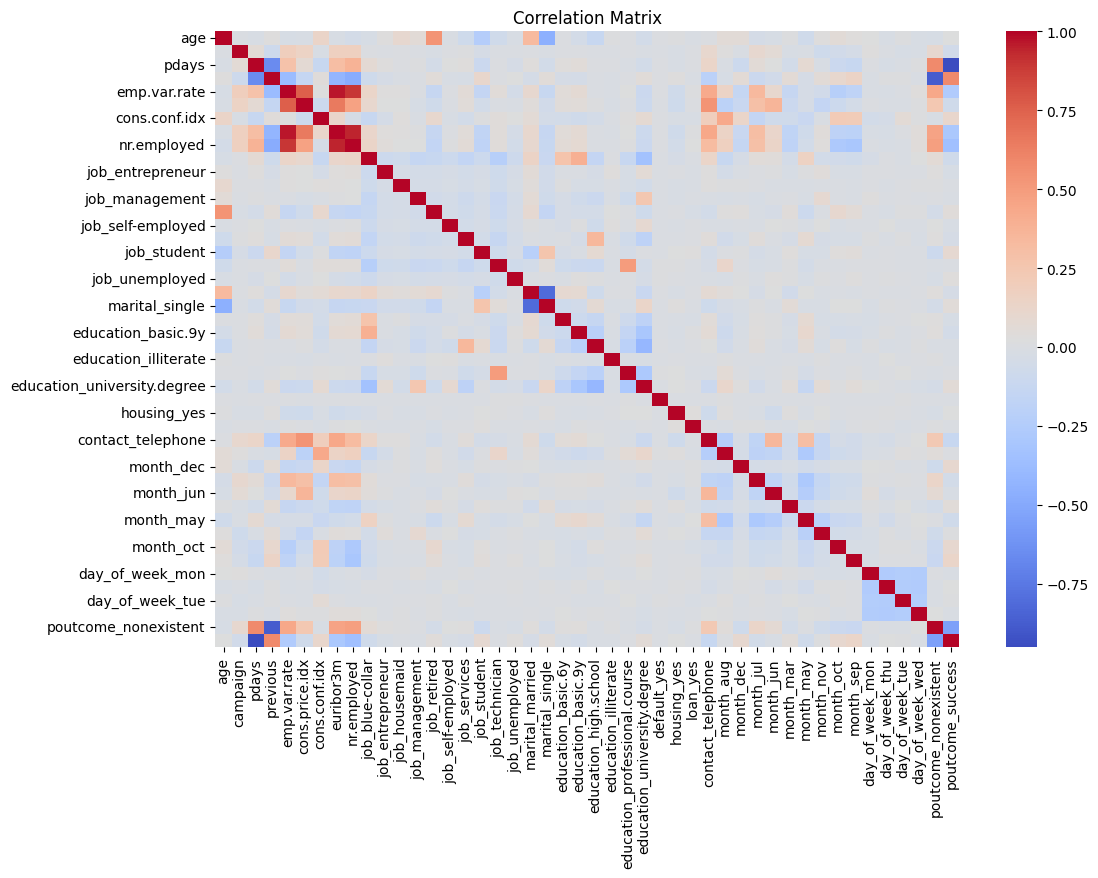

In [ ]:
import pandas as pd

# Convert back to DataFrame
X_train_ad_df = pd.DataFrame(X_train_ad, columns=X.columns)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(X_train_ad_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

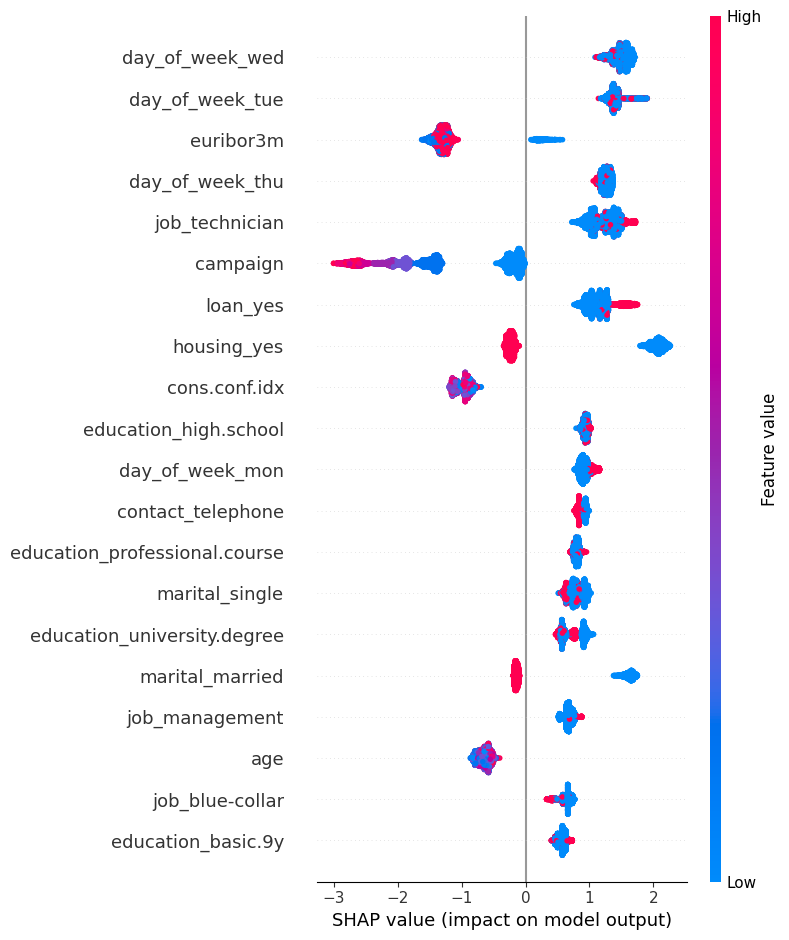

In [23]:
# ==============================
#SHAP (Random Forest)
# ==============================

import shap
import pandas as pd


rf_model = model.best_estimator_.named_steps['model']

X_test_df = pd.DataFrame(X_test, columns=X.columns)


explainer = shap.TreeExplainer(rf_model)


shap_values = explainer.shap_values(X_test_df)


shap.summary_plot(shap_values, X_test_df)

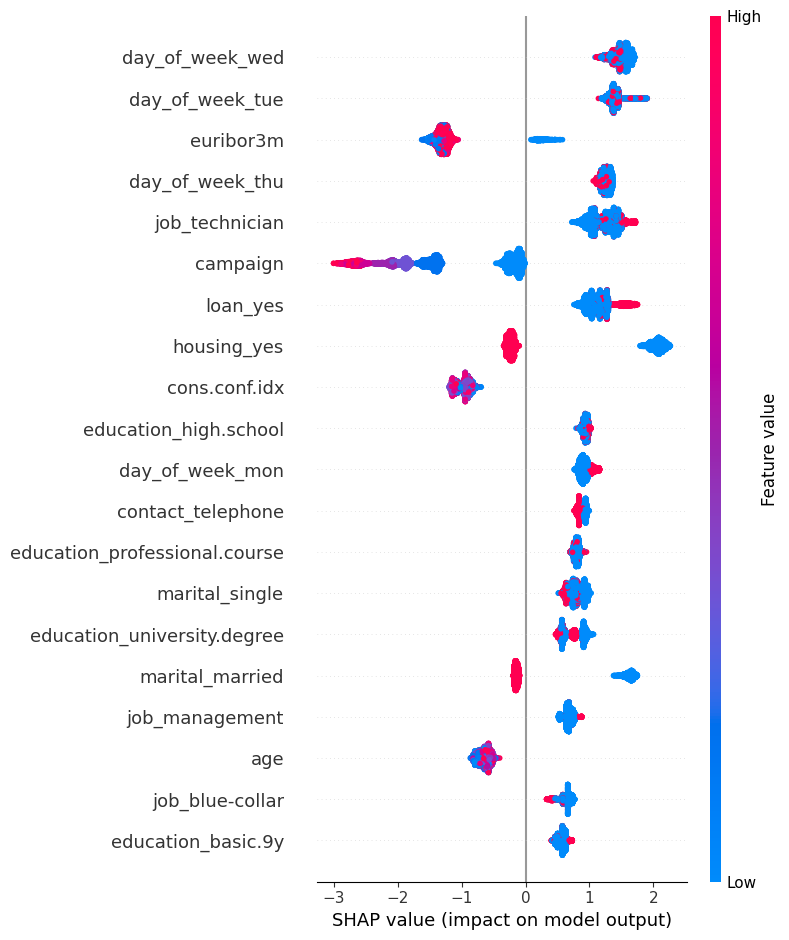

In [24]:
# ==============================
# SHAP (XGBOOST)
# ==============================

import shap
import pandas as pd


xgb_model = model.best_estimator_.named_steps['model']


X_test_df = pd.DataFrame(X_test, columns=X.columns)

explainer = shap.TreeExplainer(xgb_model)


shap_values = explainer.shap_values(X_test_df)


shap.summary_plot(shap_values, X_test_df)

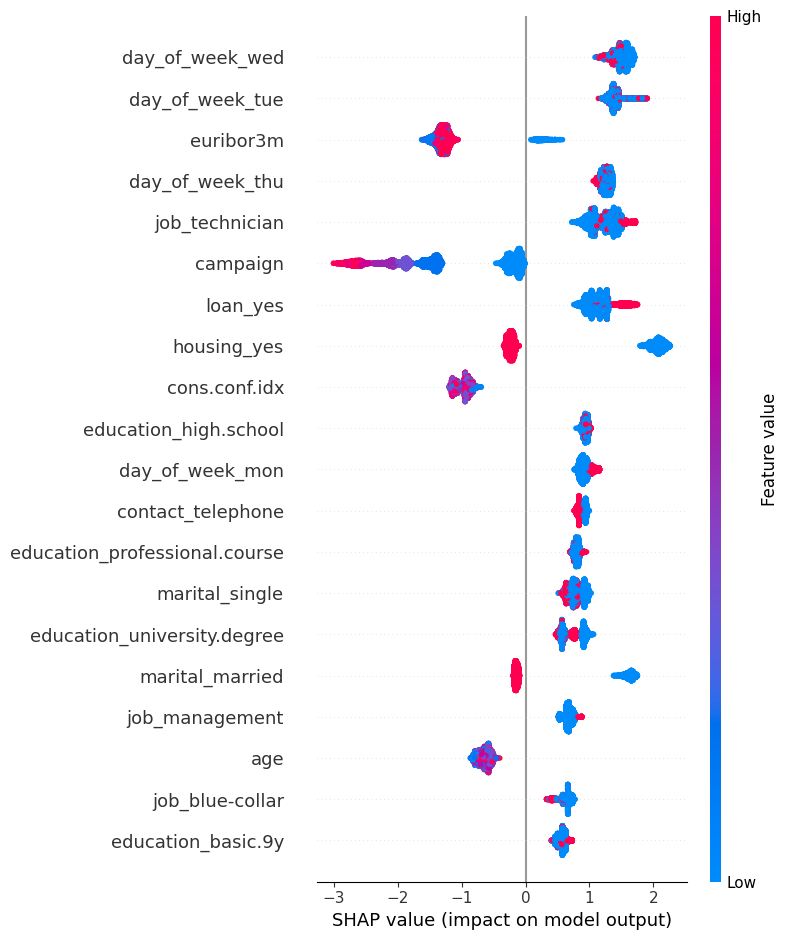

In [25]:
# ==============================
# SHAP (LIGHTGBM)
# ==============================

import shap
import pandas as pd


lgb_model = model.best_estimator_.named_steps['model']


X_test_df = pd.DataFrame(X_test, columns=X.columns)


explainer = shap.TreeExplainer(lgb_model)


shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

  0%|          | 0/50 [00:00<?, ?it/s]

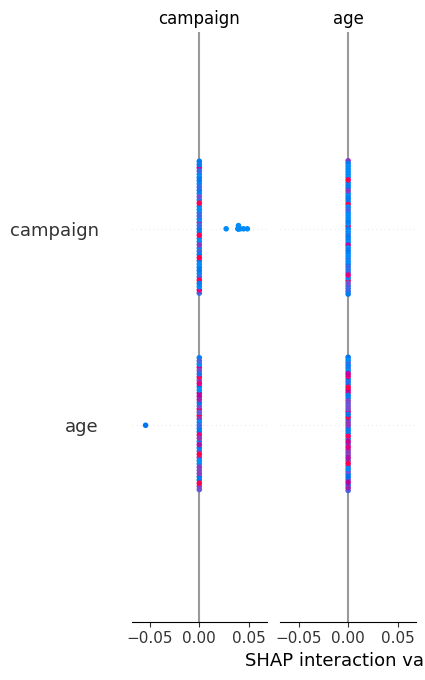

In [26]:
# ==============================
# SHAP  (KNN)
# ==============================

import shap
import pandas as pd


knn_model = model.best_estimator_.named_steps['model']


X_train_df = pd.DataFrame(X_train_ad, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)


X_sample = X_train_df.sample(100, random_state=42)


explainer = shap.KernelExplainer(knn_model.predict_proba, X_sample)


shap_values = explainer.shap_values(X_test_df[:50])


shap.summary_plot(shap_values, X_test_df[:50])

  0%|          | 0/50 [00:00<?, ?it/s]

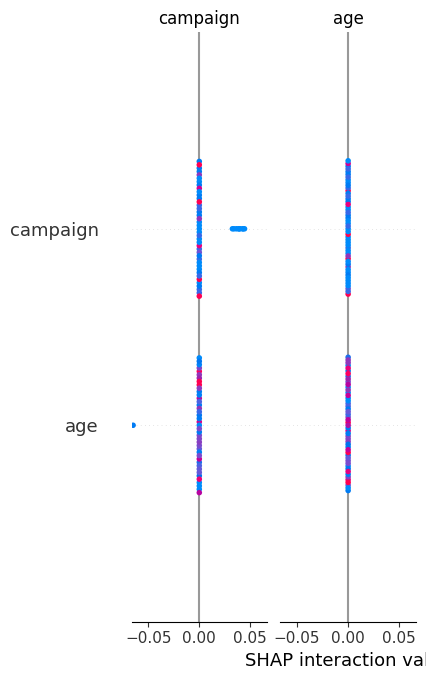

In [27]:
# ==============================
# SHAP  (BAGGING)
# ==============================

import shap
import pandas as pd


bag_model = model.best_estimator_.named_steps['model']


X_train_df = pd.DataFrame(X_train_ad, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)


X_sample = X_train_df.sample(100, random_state=42)

explainer = shap.KernelExplainer(bag_model.predict_proba, X_sample)


shap_values = explainer.shap_values(X_test_df[:50])


shap.summary_plot(shap_values, X_test_df[:50])

  0%|          | 0/50 [00:00<?, ?it/s]

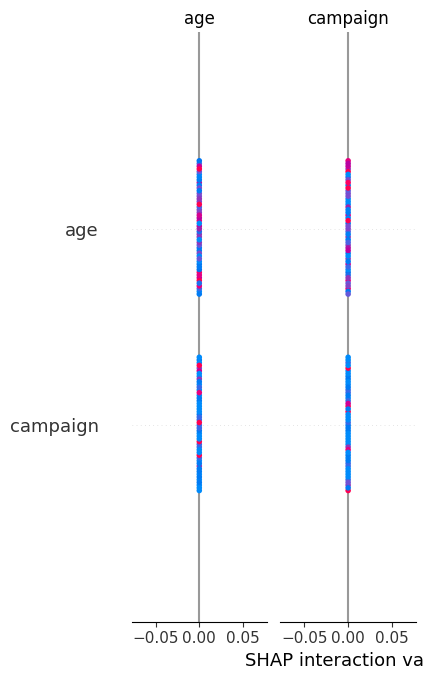

In [28]:
# ==============================
# SHAP (STACKING)
# ==============================

import shap
import pandas as pd


X_train_df = pd.DataFrame(X_train_ad, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)


X_sample = X_train_df.sample(100, random_state=42)


explainer = shap.KernelExplainer(stacking_model.predict_proba, X_sample)


shap_values = explainer.shap_values(X_test_df[:50])


shap.summary_plot(shap_values, X_test_df[:50])